# Employee Attrition Prediction

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve)

import warnings
warnings.filterwarnings("ignore")

# 1) Load Dataset

In [89]:
df = pd.read_csv(r"C:\Users\amans\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Loaded Successfully")
df.head(10)

Dataset Loaded Successfully


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


# 2) Dataset Exploration

In [90]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [91]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


In [92]:
print("\nTarget Column:")
print("Attrition")


Target Column:
Attrition


In [93]:
print("\nAttrition Count:")
print(df["Attrition"].value_counts())


Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [94]:
print(X_train.dtypes)

Age                         int64
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrM

In [95]:
num_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

cat_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns

# 3) Missing Values

In [96]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# 4) Remove Unnecessary Columns

In [97]:
drop_cols = [
    "EmployeeNumber",
    "Over18",
    "StandardHours",
    "EmployeeCount"
]

df.drop(columns=drop_cols, inplace=True)

print("Columns Removed Successfully")

Columns Removed Successfully


# 5) Convert Target Variable

In [98]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

Attrition
0    1233
1     237
Name: count, dtype: int64

# 6) EDA - Attrition by Department

In [99]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
)*100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


# 7) Chart 1 Department Attrition

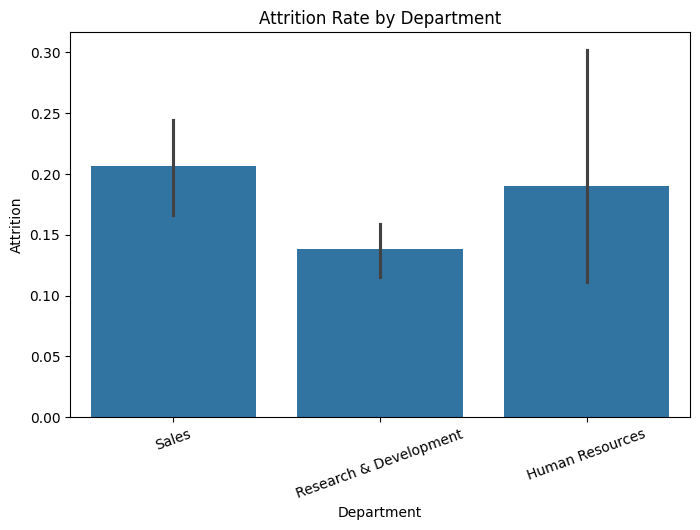

In [100]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Department",
    y="Attrition",
    data=df
)

plt.title("Attrition Rate by Department")
plt.xticks(rotation=20)

plt.savefig("chart_department.png")
plt.show()

# 8) Attrition by Job Role

In [101]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)*100

jobrole_attrition.sort_values(1, ascending=False)

Attrition,0,1
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


# 9) Monthly Income vs Attrition

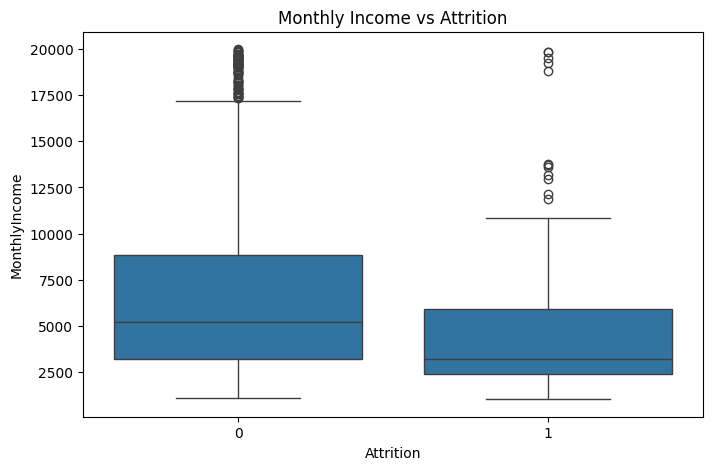

In [102]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.savefig("chart_income.png")
plt.show()

# 10) Employee Attrition Distribution

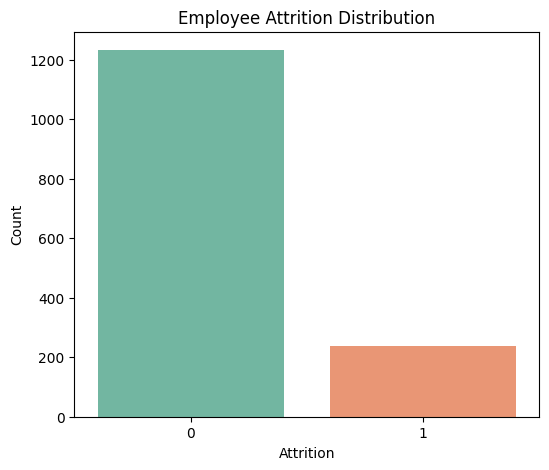

In [103]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Attrition",
    data=df,
    palette="Set2"
)

plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition")

plt.ylabel("Count")

plt.show()

# 11) Pie Chart

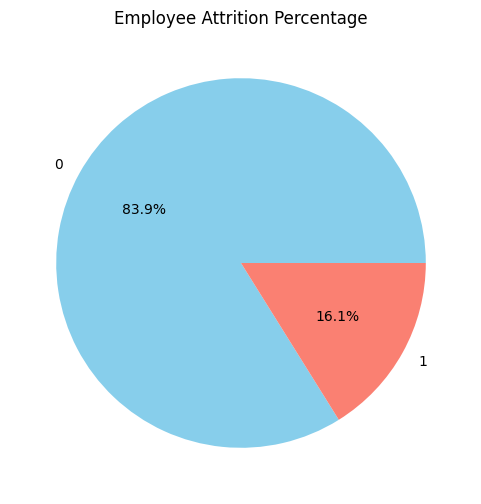

In [104]:
plt.figure(figsize=(6,6))

df["Attrition"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","salmon"]
)

plt.ylabel("")

plt.title("Employee Attrition Percentage")

plt.show()

# 12) Work Life Balance vs Attrition

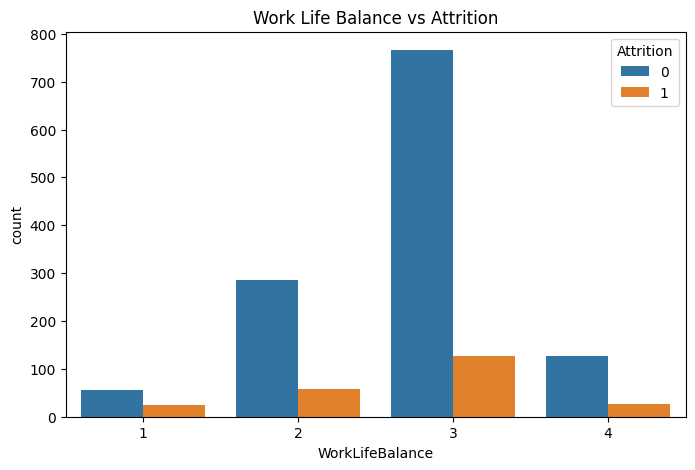

In [105]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=df
)

plt.title("Work Life Balance vs Attrition")
plt.show()

# 13) Years At Company vs Attrition

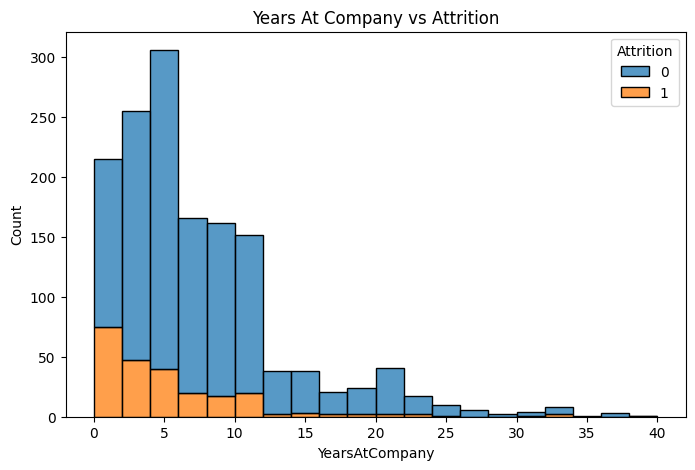

In [106]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    bins=20,
    multiple="stack"
)

plt.title("Years At Company vs Attrition")
plt.show()

# 14) Correlation Heatmap

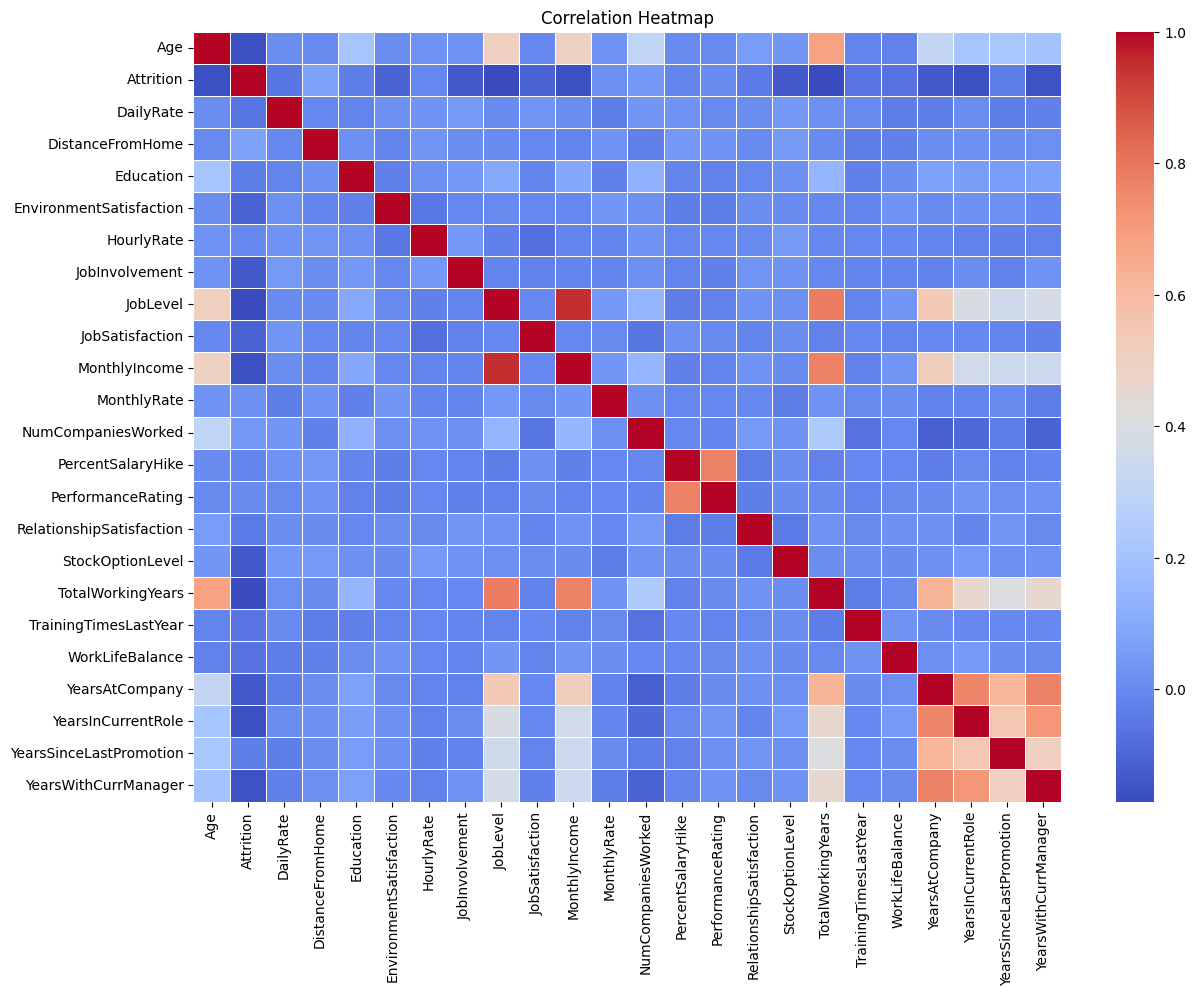

In [107]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# 15) Feature & Target Split

In [152]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# 16) Preprocessing Pipeline

In [138]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# 17) Train Test Split

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 30)
(294, 30)


# 18) Logistic Regression

In [111]:
lr_model = LogisticRegression()
lr_model

LogisticRegression()

# 19) Random Forest

In [112]:
rf_model = RandomForestClassifier()
rf_model

RandomForestClassifier()

# 20) Gradient Boosting

In [113]:
gb_model = GradientBoostingClassifier()

gb_model

GradientBoostingClassifier()

# 21) Logistic Regression Pipeline

In [114]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

lr_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWork...
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [115]:
X_train, y_train

(      Age     BusinessTravel  DailyRate              Department  \
 1194   47      Travel_Rarely       1225                   Sales   
 128    22      Travel_Rarely        594  Research & Development   
 810    46      Travel_Rarely        406                   Sales   
 478    25      Travel_Rarely        622                   Sales   
 491    43  Travel_Frequently       1001  Research & Development   
 ...   ...                ...        ...                     ...   
 1213   23      Travel_Rarely        427                   Sales   
 963    38      Travel_Rarely       1009                   Sales   
 734    22      Travel_Rarely        217  Research & Development   
 1315   36      Travel_Rarely        430  Research & Development   
 1292   39  Travel_Frequently        766                   Sales   
 
       DistanceFromHome  Education    EducationField  EnvironmentSatisfaction  \
 1194                 2          4     Life Sciences                        2   
 128                

In [116]:
print(X.dtypes)

Age                         int64
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrM

# 22) Random Forest Pipeline

In [117]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWork...
      dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [118]:
X_train, y_train

(      Age     BusinessTravel  DailyRate              Department  \
 1194   47      Travel_Rarely       1225                   Sales   
 128    22      Travel_Rarely        594  Research & Development   
 810    46      Travel_Rarely        406                   Sales   
 478    25      Travel_Rarely        622                   Sales   
 491    43  Travel_Frequently       1001  Research & Development   
 ...   ...                ...        ...                     ...   
 1213   23      Travel_Rarely        427                   Sales   
 963    38      Travel_Rarely       1009                   Sales   
 734    22      Travel_Rarely        217  Research & Development   
 1315   36      Travel_Rarely        430  Research & Development   
 1292   39  Travel_Frequently        766                   Sales   
 
       DistanceFromHome  Education    EducationField  EnvironmentSatisfaction  \
 1194                 2          4     Life Sciences                        2   
 128                

# 23) Gradient Boosting Pipeline

In [119]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWork...
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str'))])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [120]:
X_train, y_train

(      Age     BusinessTravel  DailyRate              Department  \
 1194   47      Travel_Rarely       1225                   Sales   
 128    22      Travel_Rarely        594  Research & Development   
 810    46      Travel_Rarely        406                   Sales   
 478    25      Travel_Rarely        622                   Sales   
 491    43  Travel_Frequently       1001  Research & Development   
 ...   ...                ...        ...                     ...   
 1213   23      Travel_Rarely        427                   Sales   
 963    38      Travel_Rarely       1009                   Sales   
 734    22      Travel_Rarely        217  Research & Development   
 1315   36      Travel_Rarely        430  Research & Development   
 1292   39  Travel_Frequently        766                   Sales   
 
       DistanceFromHome  Education    EducationField  EnvironmentSatisfaction  \
 1194                 2          4     Life Sciences                        2   
 128                

# 24) Column Transformer

In [121]:
# Convert all pandas StringDtype columns to object

for col in X_train.columns:
    if str(X_train[col].dtype) == "string":
        X_train[col] = X_train[col].astype(object)
        X_test[col] = X_test[col].astype(object)

In [122]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(categorical_cols)
print(numerical_cols)

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

In [125]:
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [126]:
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# 25) Evaluation Function

In [140]:
def evaluate_model(model_name, y_true, y_pred, y_prob):

    print("\n" + "="*60)
    print(f"MODEL : {model_name}")
    print("="*60)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    auc_score = roc_auc_score(y_true, y_prob)

    print("\nROC-AUC Score:", round(auc_score, 4))

    return auc_score

# 26) Model Evaluation

In [141]:
def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    print("="*50)
    print(name)

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    roc = roc_auc_score(
        y_true,
        y_prob
    )

    print("ROC AUC:", round(roc,4))

    return roc

# 27) ROC Curve Comparison

In [142]:
# 1. Train the models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# 2. Predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# 3. Prediction probabilities
lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# 4. Evaluation
lr_auc = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
rf_auc = evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
gb_auc = evaluate_model("Gradient Boosting", y_test, gb_pred, gb_prob)

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

ROC AUC: 0.8115
Random Forest
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294

ROC AUC: 0.787
Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.79      0.60      0.63  

In [143]:
print(type(lr_model))
print(type(rf_model))
print(type(gb_model))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


# 28) Comparison Table

In [144]:
# Numerical columns
num_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
cat_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)

Numerical Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [153]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [146]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC_AUC":[
        lr_auc,
        rf_auc,
        gb_auc
    ]
})

comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
0,Logistic Regression,0.811526
2,Gradient Boosting,0.805065
1,Random Forest,0.786976


# 29) Best Model

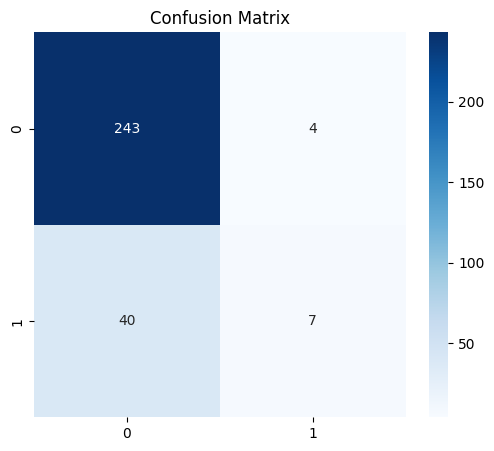

In [147]:
best_model = rf_model

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("chart_confusion_matrix.png")
plt.show()

# 30) Feature Importance 

In [148]:


# Get fitted preprocessor
preprocessor = best_model.named_steps["preprocessor"]

# Get categorical transformer
cat_transformer = preprocessor.named_transformers_["cat"]

# Check whether it's a Pipeline or OneHotEncoder
if hasattr(cat_transformer, "named_steps"):
    ohe = cat_transformer.named_steps["onehot"]
else:
    ohe = cat_transformer

# Feature names
cat_feature_names = ohe.get_feature_names_out(cat_features)

feature_names = np.concatenate([
    num_features,
    cat_feature_names
])

# Feature importances
importances = best_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                 Feature  Importance
9          MonthlyIncome    0.076521
0                    Age    0.061227
16     TotalWorkingYears    0.059397
1              DailyRate    0.052957
10           MonthlyRate    0.044919
5             HourlyRate    0.044488
2       DistanceFromHome    0.043076
22  YearsWithCurrManager    0.037161
19        YearsAtCompany    0.035469
12     PercentSalaryHike    0.032828


# 31) Top 10 Feature Importance Chart

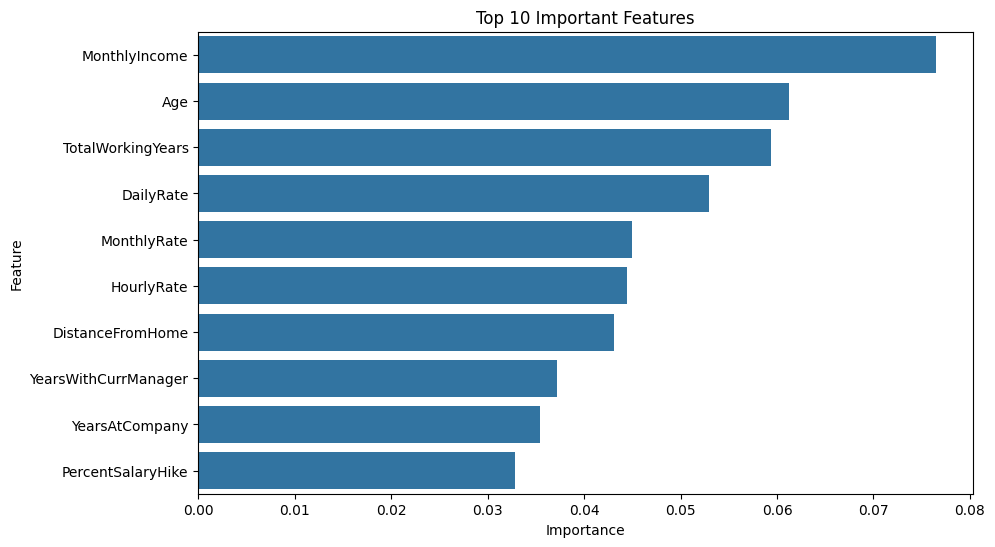

In [149]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Important Features")

plt.savefig("chart_feature_importance.png")
plt.show()

# 32 ROC Curve Comparison

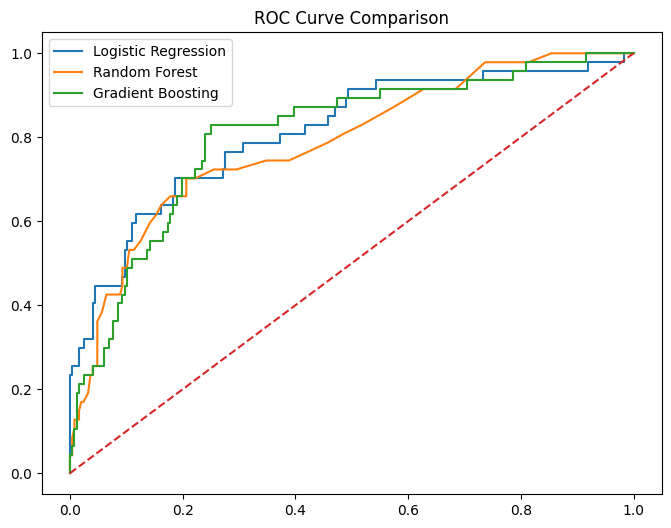

In [150]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label="Gradient Boosting"
)

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("ROC Curve Comparison")

plt.savefig("chart_roc_curve.png")
plt.show()